# Señal AIS sintética (GMSK con NRZI y Bit Stuffing) - generación, envío a la Red Pitaya y demodulación

Hace uso de las librerías (`gmsk_tx_signal`, `redpitaya_io`, `gmsk_demod`) y agrega lógica para el bit stuffing HDLC real.

In [12]:
# ============================================================
# CELDA 0 — Imports y parametros
# ============================================================
import sys
sys.path.insert(0, '.')   # los .py de la libreria estan en esta carpeta

import numpy as np

import gmsk_tx_signal as txlib
import redpitaya_io as rpio
import gmsk_demod as demod

from gmsk_tx_signal import N_PREAMBULO, START_FLAG, N_PAYLOAD, N_FCS, N_RANURA

# ---------------- parametros del receptor y de la señal ----------------
FS      = 125e6                 # tasa del DAC/ADC
fs_out  = 125e6 / 651            # tasa de salida del receptor (192.012 ksps)
f_lo    = 10.7e6                 # LO del receptor
OFFSET  = 0e3                    # offset de portadora sobre el LO
BAUD    = 9600.0                 # AIS: 9600 bit/s
BT      = 0.4                    # AIS: BT nominal 0.4 (ITU-R M.1371)
L_PULSO = 4                      # duración del pulso en simbolos

AMPLITUD = 4000
TX_BURST_SAMPLES = 32

SPS_TX = round(FS / BAUD)        # muestras/simbolo en el DAC
SPS_RX = fs_out / BAUD           # muestras/simbolo en el receptor

HOST = '192.168.1.100'
PORT = 1003

print(f"SPS_TX = {SPS_TX}   SPS_RX = {SPS_RX:.4f}")
print(f"Ranura nominal (sin stuffing): {N_RANURA} bits")


SPS_TX = 13021   SPS_RX = 20.0013
Ranura nominal (sin stuffing): 224 bits


In [13]:
# ============================================================
# CELDA 1 — Generacion de la senal de prueba (gmsk_tx_signal)
# ============================================================

rng = np.random.RandomState(2024)
words_tx, fc_adj, N_buf, bb_ranura, bits_trama, payload_tx = \
    txlib.generar_senal_ais_prueba(rng, FS, f_lo, OFFSET, SPS_TX, L_PULSO, BT,
                                    AMPLITUD, TX_BURST_SAMPLES)
N_RANURA_REAL = len(bits_trama)
CFO_REAL = fc_adj - f_lo


In [14]:
# ============================================================
# CELDA 2 — Comunicacion con el servidor de la Red Pitaya (redpitaya_io)
# ============================================================
cfg_reset, cfg_run = rpio.calcular_pinc_y_cfg(f_lo, FS)

N_RX = 12000   # muestras complejas por captura

sock = rpio.abrir_y_arrancar(HOST, PORT, words_tx, cfg_reset, cfg_run)
print(f"Conectado a {HOST}:{PORT}, TX corriendo en loop continuo.")
print(f"Captura de {N_RX} muestras = {N_RX/fs_out*1e3:.1f} ms "
      f"({N_RX/fs_out*BAUD:.0f} simbolos, "
      f"{N_RX/fs_out*BAUD/N_RANURA_REAL:.1f} ranuras)")

# SNR real lograda con la amplitud actual (AMPLITUD, Celda 0): se mide la
# potencia de la señal activa contra el piso de ruido real (TX apagado).
iq_prueba = rpio.read_adc(sock, N_RX)
m = np.abs(iq_prueba); activo = m > 0.5*np.max(m)
P_senal = (float(np.mean(np.abs(iq_prueba[activo]-np.mean(iq_prueba))**2))
           if np.any(activo) else float('nan'))

rpio.tx_stop(sock)
iq_ruido = rpio.read_adc(sock, N_RX)
P_ruido = float(np.mean(np.abs(iq_ruido-np.mean(iq_ruido))**2))
rpio.tx_load_and_start(sock, words_tx)

SNR_MEDIDA_DB = 10*np.log10(P_senal/P_ruido)
print(f"SNR real medida (AMPLITUD={AMPLITUD}): {SNR_MEDIDA_DB:.1f} dB")


Conectado a 192.168.1.100:1003, TX corriendo en loop continuo.
Captura de 12000 muestras = 62.5 ms (600 simbolos, 2.6 ranuras)
SNR real medida (AMPLITUD=4000): 84.8 dB


In [15]:
# ============================================================
# CELDA 3 — Receptor AIS con destuffing (sobre gmsk_demod)
# ============================================================
# Delimitacion por flag HDLC, avance bit a bit destuffeando datos+FCS, 
# y verificacion de CRC como chequeo de integridad real.

from scipy.interpolate import interp1d


def bit_destuff_avanzar(bits, i0, n_necesarios):
    """Camina bits[i0:] destuffeando (descarta el '0' insertado despues
    de cada racha de 5 unos) hasta acumular exactamente n_necesarios
    bits destuffeados. Devuelve (bits_destuffeados, i_fin) -- i_fin es el
    indice en el array ORIGINAL inmediatamente despues del ultimo bit
    consumido (incluyendo el '0' de stuffing pendiente si la ultima
    racha llego a 5 justo en el borde) -- o (None, None) si se acaban
    los bits antes de completar, o si se viola la regla de stuffing
    (dato corrupto)."""
    destuffed = []
    unos = 0
    i = i0
    n = len(bits)
    while len(destuffed) < n_necesarios:
        if i >= n:
            return None, None
        b = int(bits[i])
        if unos == 5:
            if b != 0:
                return None, None
            unos = 0
            i += 1
            continue
        destuffed.append(b)
        unos = unos + 1 if b == 1 else 0
        i += 1
    if unos == 5:
        if i >= n or int(bits[i]) != 0:
            return None, None
        i += 1
    return np.array(destuffed, dtype=np.uint8), i


class RxGmskCiego(demod.ReceptorGmskCiego):
    """Receptor feedforward (gmsk_demod) + delimitacion de trama por flag
    HDLC exacto + destuffing + verificacion de CRC."""

    def __init__(self, iq, sps):
        super().__init__(iq, fs_out, sps)
        # contadores de diagnostico, poblados por payloads()
        self.n_candidatos_flag = 0   # cuantas veces aparecio el flag
        self.n_descartadas_crc = 0   # de esos, cuantos fallaron el CRC
        self.n_aceptadas = 0
        self.debug = []

    def payloads(self):
        self.n_candidatos_flag = 0
        self.n_descartadas_crc = 0
        self.n_aceptadas = 0
        self.debug = []

        soft = self.soft()
        if len(soft) < int(N_RANURA * self.sps):
            return []

        f = interp1d(np.arange(len(soft)), soft, kind='linear', fill_value='extrapolate')
        flag = np.array([int(c) for c in START_FLAG], dtype=np.uint8)
        flag_inv = 1 - flag
        npat = len(flag)

        def bits_con_tau(tau_):
            bits_crudos, symbols, positions = self.bits_con_tau(tau_)
            bits = demod.nrzi_decode(bits_crudos)
            return bits, symbols, positions

        def encontrar_flags(bits):
            candidatos = []
            for i in range(len(bits) - npat + 1):
                if np.array_equal(bits[i:i+npat], flag):
                    candidatos.append((i, False))
                elif np.array_equal(bits[i:i+npat], flag_inv):
                    candidatos.append((i, True))
            return candidatos

        tau0 = demod.recuperar_fase_simbolo(soft, self.sps)
        bits0, symbols0, positions0 = bits_con_tau(tau0)
        candidatos = encontrar_flags(bits0)
        self.n_candidatos_flag = len(candidatos)

        resultados = []
        for i_flag, invertir in candidatos:
            symbols_f, positions_f, bits_f = symbols0, positions0, bits0

            # refinar tau con el training de esta trama especifica
            i0_train = i_flag - N_PREAMBULO
            if i0_train >= 0:
                s0 = int(positions0[i0_train]); s1 = int(positions0[i_flag])
                if s1 - s0 > self.sps * 4:
                    tau_local = demod.recuperar_fase_simbolo(soft[s0:s1], self.sps)
                    tau_ref = ((s0 + tau_local*self.sps) % self.sps) / self.sps
                    bits_r, symbols_r, positions_r = bits_con_tau(tau_ref)
                    bits_r_norm = (1 - bits_r) if invertir else bits_r
                    for di in range(-2, 3):
                        ii = i_flag + di
                        if ii < 0 or ii + npat > len(bits_r_norm):
                            continue
                        if np.array_equal(bits_r_norm[ii:ii+npat], flag):
                            i_flag = ii
                            symbols_f, positions_f, bits_f = symbols_r, positions_r, bits_r
                            break

            # continua local final (solo training), sobre la grilla ya refinada
            i0_train = i_flag - N_PREAMBULO
            dc = np.median(symbols_f[i0_train:i_flag]) if i0_train >= 0 else np.median(symbols_f)
            bits_final_crudos = (symbols_f - dc > 0).astype(np.uint8)
            bits_final = demod.nrzi_decode(bits_final_crudos)
            if invertir:
                bits_final = 1 - bits_final

            if not np.array_equal(bits_final[i_flag:i_flag+npat], flag):
                continue   # el refinamiento desalineo el flag, descartar

            # destuffear datos+FCS caminando bit a bit desde justo
            # despues del start flag
            datos_fcs, i_fin = bit_destuff_avanzar(bits_final, i_flag+npat, N_PAYLOAD+N_FCS)
            if datos_fcs is None:
                continue   # violacion de stuffing o se corto la captura

            # el end flag debe aparecer exacto justo despues del ultimo
            # bit destuffeado
            if i_fin+npat > len(bits_final) or not np.array_equal(bits_final[i_fin:i_fin+npat], flag):
                continue

            datos = datos_fcs[:N_PAYLOAD].astype(np.uint8)
            fcs_bits = datos_fcs[N_PAYLOAD:N_PAYLOAD+N_FCS]

            fcs_calculado = txlib.crc16_ccitt(datos)
            fcs_recibido = 0
            for bit in fcs_bits:
                fcs_recibido = (fcs_recibido << 1) | int(bit)
            if fcs_calculado != fcs_recibido:
                self.n_descartadas_crc += 1
                continue

            self.debug.append(dict(i_flag=i_flag, symbols=symbols_f, positions=positions_f,
                                    dc=dc, bits=bits_final, i_fin=i_fin, invertir=invertir))
            resultados.append(datos)

        self.n_aceptadas = len(resultados)
        return resultados


print("Receptor AIS definido (gmsk_demod.ReceptorGmskCiego + flag exacto + destuffing + CRC).")


Receptor AIS definido (gmsk_demod.ReceptorGmskCiego + flag exacto + destuffing + CRC).


In [16]:
# ============================================================
# CELDA 4 — Verificacion rapida: capturas reales, BER y estadisticas
# ============================================================

N_INTENTOS = 12

bers = []
tramas_por_captura = []
sin_trama = 0
total_candidatos_flag = 0
total_descartadas_crc = 0

print(f"=== Corriendo {N_INTENTOS} capturas reales por la Red Pitaya ===")
for intento in range(N_INTENTOS):
    iq = rpio.read_adc(sock, N_RX)
    iq = iq / (np.max(np.abs(iq)) + 1e-12)

    rx = RxGmskCiego(iq, SPS_RX)
    rx.run()

    if intento == 0:
        print(f"      CFO estimado: {rx.offset_est/1e3:.3f} kHz "
              f"(objetivo {CFO_REAL/1e3:.3f} kHz, "
              f"error {(rx.offset_est-CFO_REAL):.1f} Hz)")

    pls = rx.payloads()
    tramas_por_captura.append(len(pls))
    total_candidatos_flag += rx.n_candidatos_flag
    total_descartadas_crc += rx.n_descartadas_crc

    if not pls:
        sin_trama += 1
        print(f"  intento {intento+1:2d}/{N_INTENTOS}: sin trama aceptada "
              f"({rx.n_candidatos_flag} apariciones del flag, "
              f"{rx.n_descartadas_crc} con CRC invalido)")
        continue

    for pl in pls:
        err = int(np.sum(pl != np.array(payload_tx, dtype=np.uint8)))
        bers.append(err / N_PAYLOAD)

    mejor = min(bers[-len(pls):])
    print(f"  intento {intento+1:2d}/{N_INTENTOS}: {len(pls)} trama(s) aceptada(s), "
          f"mejor BER={mejor:.4f}  ({rx.n_candidatos_flag} apariciones del flag, "
          f"{rx.n_descartadas_crc} con CRC invalido)")

bers = np.array(bers)
print(f"\n=== Estadisticas ===")
print(f"Capturas sin trama aceptada  : {sin_trama}/{N_INTENTOS}")
print(f"Tramas aceptadas en total    : {len(bers)}")
print(f"Apariciones del flag (total) : {total_candidatos_flag}")
print(f"Con CRC invalido (total)     : {total_descartadas_crc}")
if len(bers):
    print(f"BER media   : {bers.mean():.4f}")
    print(f"BER mediana : {np.median(bers):.4f}")
    print(f"BER min/max : {bers.min():.4f} / {bers.max():.4f}")
    print(f"Tramas con BER = 0    : {int(np.sum(bers == 0))}/{len(bers)}")
    print(f"Tramas con BER < 0.05 : {int(np.sum(bers < 0.05))}/{len(bers)}")
else:
    print("No se acepto ninguna trama.")


=== Corriendo 12 capturas reales por la Red Pitaya ===
      CFO estimado: -0.231 kHz (objetivo 0.019 kHz, error -250.4 Hz)
  intento  1/12: 2 trama(s) aceptada(s), mejor BER=0.0000  (6 apariciones del flag, 0 con CRC invalido)
  intento  2/12: 2 trama(s) aceptada(s), mejor BER=0.0000  (8 apariciones del flag, 0 con CRC invalido)
  intento  3/12: 2 trama(s) aceptada(s), mejor BER=0.0000  (7 apariciones del flag, 0 con CRC invalido)
  intento  4/12: 2 trama(s) aceptada(s), mejor BER=0.0000  (6 apariciones del flag, 0 con CRC invalido)
  intento  5/12: 2 trama(s) aceptada(s), mejor BER=0.0000  (9 apariciones del flag, 0 con CRC invalido)
  intento  6/12: 2 trama(s) aceptada(s), mejor BER=0.0000  (9 apariciones del flag, 0 con CRC invalido)
  intento  7/12: 2 trama(s) aceptada(s), mejor BER=0.0000  (8 apariciones del flag, 0 con CRC invalido)
  intento  8/12: 2 trama(s) aceptada(s), mejor BER=0.0000  (7 apariciones del flag, 0 con CRC invalido)
  intento  9/12: 2 trama(s) aceptada(s), mej

In [17]:
# ============================================================
# CELDA 5 — Utilidades de medicion y estilo de las figuras
# ============================================================
import os
import matplotlib.pyplot as plt
from scipy import signal as sg

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'font.size': 9,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.titlesize': 10, 'legend.fontsize': 8})

DIR_FIG = 'figuras_informe'
os.makedirs(DIR_FIG, exist_ok=True)

# reconstruye las muestras con signo de un buffer de 14 bits empaquetado
# como en words_tx -- usado por la figura del espectro para graficar el
# espectro del buffer real del DAC
ADC_BITS = 14

def _signed_adc14(words):
    w = np.asarray(words, dtype=np.int32) & ((1 << ADC_BITS) - 1)
    sign = 1 << (ADC_BITS - 1)
    return np.where(w & sign, w - (1 << ADC_BITS), w).astype(np.float64)


def captura(seed=None, n=N_RX, snr_db=None):
    """Una captura real por la Red Pitaya. seed/snr_db se aceptan por
    compatibilidad (no tienen efecto: sobre hardware real no hay
    semilla de ruido ni SNR inyectable por software)."""
    return rpio.read_adc(sock, n)


def diagnostico(iq, sps=SPS_RX):
    """Corre el receptor sobre una captura y devuelve las tramas
    aceptadas junto con la info intermedia (rx.debug) para graficar."""
    rx = RxGmskCiego(np.asarray(iq, dtype=np.complex64), sps)
    rx.run()
    pls = rx.payloads()
    return {'rx': rx, 'iq': rx.iq, 'f_est': rx.offset_est,
            'payloads': pls, 'debug': rx.debug, 'soft': rx.soft()}


def captura_util(seed0=0, margen=40):
    """Busca una captura con al menos una trama aceptada y con margen
    suficiente para ver el training completo en las figuras."""
    for s in range(seed0, seed0 + 200):
        iq = captura(s)
        d = diagnostico(iq)
        if not d['debug']:
            continue
        g = d['debug'][0]
        i0 = g['i_flag'] - N_PREAMBULO
        if i0 >= 0 and g['i_fin'] + margen <= len(g['bits']):
            return iq, d, g, s
    raise RuntimeError('no se encontro una captura con una trama completa')


p_tx = np.array(payload_tx, dtype=np.uint8)
IQ_REF, DIAG_REF, _g = None, None, None
IQ_REF, DIAG_REF, _g, SEED_REF = captura_util()
G_REF = dict(pos=_g['positions'], sym=_g['symbols'] - _g['dc'], bits=_g['bits'],
             dc=_g['dc'], i_flag=_g['i_flag'], inv=_g['invertir'], i_fin=_g['i_fin'])

print(f"Captura de referencia: semilla {SEED_REF}, flag de inicio en el "
      f"simbolo {G_REF['i_flag']}")
print(f"CFO estimado {DIAG_REF['f_est']:.1f} Hz (real {CFO_REAL:.1f} Hz, "
      f"error {DIAG_REF['f_est']-CFO_REAL:+.1f} Hz)")

Captura de referencia: semilla 0, flag de inicio en el simbolo 148
CFO estimado -228.5 Hz (real 19.3 Hz, error -247.8 Hz)


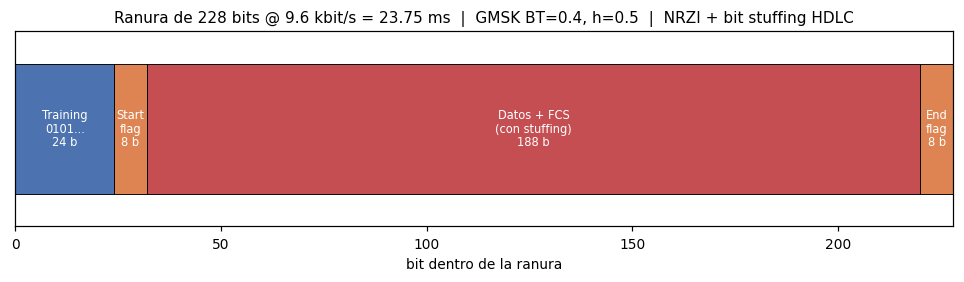

Payload de datos (primeros 32 bits): 01110110011101100010000011000111...
FCS transmitido: 0xEB4D
Bits insertados por el stuffing: 4


In [18]:
# ============================================================
# CELDA — FIGURA 1: estructura de la ranura
# ============================================================
n_datos_stuffed = N_RANURA_REAL - N_PREAMBULO - 2*len(START_FLAG)

campos = [('Training\n0101...', N_PREAMBULO, '#4C72B0'),
          ('Start\nflag',       len(START_FLAG), '#DD8452'),
          ('Datos + FCS\n(con stuffing)', n_datos_stuffed, '#C44E52'),
          ('End\nflag',         len(START_FLAG), '#DD8452')]

fig, ax = plt.subplots(figsize=(11, 2.3))
x = 0
for nom, n, col in campos:
    ax.barh(0, n, left=x, color=col, edgecolor='k', lw=0.6)
    ax.text(x + n/2, 0, f'{nom}\n{n} b', ha='center', va='center',
            fontsize=7.5, color='w')
    x += n
ax.set_xlim(0, N_RANURA_REAL); ax.set_ylim(-0.6, 0.6)
ax.set_yticks([]); ax.grid(False)
ax.set_xlabel('bit dentro de la ranura')
ax.set_title(f'Ranura de {N_RANURA_REAL} bits @ {BAUD/1e3:.1f} kbit/s = '
             f'{N_RANURA_REAL/BAUD*1e3:.2f} ms  |  GMSK BT={BT}, h=0.5  |  '
             f'NRZI + bit stuffing HDLC')
plt.show()

print(f"Payload de datos (primeros 32 bits): "
      f"{''.join(map(str, payload_tx[:32]))}...")
print(f"FCS transmitido: 0x{txlib.crc16_ccitt(payload_tx):04X}")
print(f"Bits insertados por el stuffing: {N_RANURA_REAL - N_RANURA}")

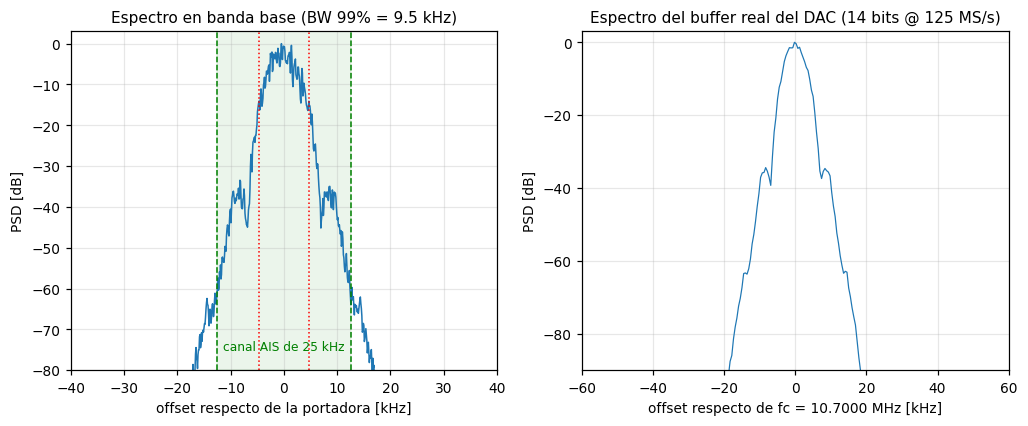

Ancho de banda 99 %            : 9.47 kHz
Potencia fuera de +-12.5 kHz   : -61.6 dBc


In [19]:
# ============================================================
# CELDA — FIGURA 3: espectro transmitido
# ============================================================
SPS_A = 20  # sps auxiliar, solo para esta figura

bits_codificados_largo = txlib.nrzi_encode(
    np.tile(np.array(bits_trama, dtype=np.uint8), 8))
_tb = txlib.TxGmsk(list(bits_codificados_largo), SPS_A, L_PULSO, BT); _tb.run()
bb_larga = _tb.baseband()

fs_a = BAUD*SPS_A
f, P = sg.welch(bb_larga, fs=fs_a, nperseg=2048, return_onesided=False, detrend=False)
f = np.fft.fftshift(f); P = np.fft.fftshift(P)
acum = np.cumsum(P)/np.sum(P)
bw99 = f[np.searchsorted(acum, 0.995)] - f[np.searchsorted(acum, 0.005)]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(f/1e3, 10*np.log10(P/P.max()), lw=1)
ax[0].axvspan(-12.5, 12.5, color='g', alpha=0.08)
for s_ in (-12.5, 12.5):
    ax[0].axvline(s_, color='g', ls='--', lw=1)
ax[0].text(0, -75, 'canal AIS de 25 kHz', ha='center', color='g', fontsize=8)
for s_ in (-1, 1):
    ax[0].axvline(s_*bw99/2/1e3, color='r', ls=':', lw=1)
ax[0].set_xlim(-40, 40); ax[0].set_ylim(-80, 3)
ax[0].set_xlabel('offset respecto de la portadora [kHz]'); ax[0].set_ylabel('PSD [dB]')
ax[0].set_title(f'Espectro en banda base (BW 99% = {bw99/1e3:.1f} kHz)')

rf = _signed_adc14(words_tx)
f2, P2 = sg.welch(rf, fs=FS, nperseg=1 << 18, detrend=False)
ax[1].plot((f2-fc_adj)/1e3, 10*np.log10(P2/P2.max()), lw=0.8)
ax[1].set_xlim(-60, 60); ax[1].set_ylim(-90, 3)
ax[1].set_xlabel(f'offset respecto de fc = {fc_adj/1e6:.4f} MHz [kHz]')
ax[1].set_ylabel('PSD [dB]')
ax[1].set_title('Espectro del buffer real del DAC (14 bits @ 125 MS/s)')

plt.show()

i25 = np.abs(f) <= 12.5e3
fuera_dbc = 10*np.log10(np.sum(P[~i25])/np.sum(P))
print(f"Ancho de banda 99 %            : {bw99/1e3:.2f} kHz")
print(f"Potencia fuera de +-12.5 kHz   : {fuera_dbc:.1f} dBc")

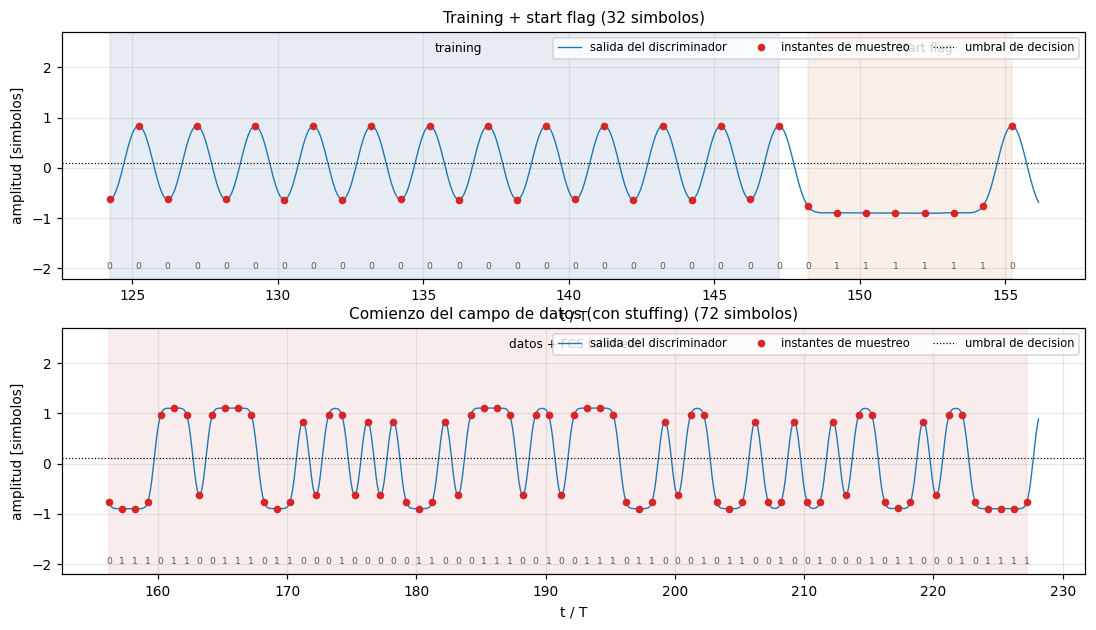

Training recuperado
Start flag recuperado : 01111110   (esperado 01111110)


In [20]:
# ============================================================
# CELDA — FIGURA 6: salida del discriminador y decision de bits
# ============================================================
soft, pos, sym, b, i_flag = DIAG_REF['soft'], G_REF['pos'], G_REF['sym'], G_REF['bits'], G_REF['i_flag']
i0 = i_flag - N_PREAMBULO

fig, ax = plt.subplots(2, 1, figsize=(12, 6.4))
ventanas = [(i0, i0 + N_PREAMBULO + len(START_FLAG), 'Training + start flag'),
            (i_flag + len(START_FLAG), min(i_flag + len(START_FLAG) + 72, len(pos)),
             'Comienzo del campo de datos (con stuffing)')]
for a, (lo, hi, tit) in zip(ax, ventanas):
    s0, s1 = int(pos[lo]), int(pos[hi-1]) + int(SPS_RX)
    a.plot(np.arange(s0, s1)/SPS_RX, soft[s0:s1], lw=0.9, color='C0',
           label='salida del discriminador')
    a.plot(pos[lo:hi]/SPS_RX, sym[lo:hi] + G_REF['dc'], 'o', ms=4, color='C3',
           label='instantes de muestreo')
    a.axhline(G_REF['dc'], color='k', ls=':', lw=0.8, label='umbral de decision')
    a.set_ylim(-2.2, 2.7); a.set_ylabel('amplitud [simbolos]')
    a.set_xlabel('t / T'); a.set_title(f'{tit} ({hi-lo} simbolos)')
    a.legend(fontsize=7.5, loc='upper right', ncol=3)
    for k in range(lo, hi):
        a.text(pos[k]/SPS_RX, -2.0, str(b[k]), fontsize=6, ha='center', color='0.35')

ax[0].axvspan(pos[i0]/SPS_RX, pos[i0+N_PREAMBULO-1]/SPS_RX, color='#4C72B0', alpha=0.13)
ax[0].text(pos[i0+N_PREAMBULO//2]/SPS_RX, 2.3, 'training', ha='center', fontsize=8)
ax[0].axvspan(pos[i_flag]/SPS_RX, pos[i_flag+len(START_FLAG)-1]/SPS_RX, color='#DD8452', alpha=0.13)
ax[0].text(pos[i_flag+len(START_FLAG)//2]/SPS_RX, 2.3, 'start flag', ha='center', fontsize=8)
fin_ventana = min(i_flag+len(START_FLAG)+71, len(pos)-1)
ax[1].axvspan(pos[i_flag+len(START_FLAG)]/SPS_RX, pos[fin_ventana]/SPS_RX,
              color='#C44E52', alpha=0.10)
ax[1].text(pos[i_flag+len(START_FLAG)+36]/SPS_RX, 2.3,
           'datos + FCS (stuffed)', ha='center', fontsize=8)

plt.show()

rec_tr = ''.join(map(str, b[i0:i0+N_PREAMBULO]))
rec_fl = ''.join(map(str, b[i_flag:i_flag+len(START_FLAG)]))
print(f"Training recuperado")
print(f"Start flag recuperado : {rec_fl}   (esperado {START_FLAG})")

Piso de ruido medido (TX apagado): P_ruido = 5.866e+07

  amplitud x0.00  SNR est.  20.4 dB: deteccion  9/20,  9 tramas aceptadas,    0 errores en  1512 bits
  amplitud x0.00  SNR est.  28.6 dB: deteccion 20/20, 31 tramas aceptadas,    0 errores en  5208 bits
  amplitud x0.01  SNR est.  38.1 dB: deteccion 20/20, 33 tramas aceptadas,    0 errores en  5544 bits
  amplitud x0.01  SNR est.  44.4 dB: deteccion 20/20, 34 tramas aceptadas,    0 errores en  5712 bits
  amplitud x0.02  SNR est.  50.7 dB: deteccion 20/20, 30 tramas aceptadas,    0 errores en  5040 bits
  amplitud x0.04  SNR est.  56.8 dB: deteccion 20/20, 31 tramas aceptadas,    0 errores en  5208 bits
  amplitud x0.08  SNR est.  62.8 dB: deteccion 20/20, 31 tramas aceptadas,    0 errores en  5208 bits
  amplitud x0.15  SNR est.  68.3 dB: deteccion 20/20, 33 tramas aceptadas,    0 errores en  5544 bits
  amplitud x0.70  SNR est.  81.7 dB: deteccion 20/20, 29 tramas aceptadas,    0 errores en  4872 bits


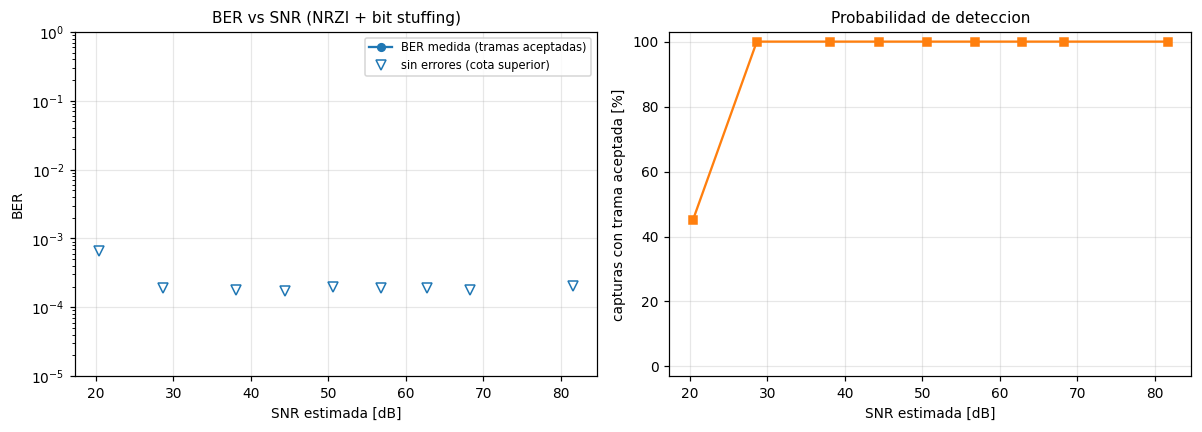

In [21]:
# ============================================================
# CELDA 4b — Barrido de amplitud: SNR real vs. deteccion, BER y CRC
# ============================================================
import matplotlib.pyplot as plt

p_tx = np.array(payload_tx, dtype=np.uint8)

AMPLITUDES_REL = [0.001, 0.002, 0.005, 0.01, 0.02, 0.04, 0.08, 0.15, 0.7]
N_CAP_SNR = 20

AMPLITUD_ORIG = AMPLITUD
words_orig = words_tx.copy()

rpio.tx_stop(sock)
iq_ruido = rpio.read_adc(sock, N_RX)
P_ruido = float(np.mean(np.abs(iq_ruido - np.mean(iq_ruido))**2))
print(f"Piso de ruido medido (TX apagado): P_ruido = {P_ruido:.3e}\n")

barr = []
for amp_rel in AMPLITUDES_REL:
    AMPLITUD = amp_rel * AMPLITUD_ORIG
    words_amp, _, _, _ = txlib.construir_buffer_dac(
        bits_trama, FS, f_lo, OFFSET, SPS_TX, L_PULSO, BT,
        AMPLITUD, TX_BURST_SAMPLES)
    rpio.tx_load_and_start(sock, words_amp)

    det = errs = nbits = nfr = 0
    candidatos_flag = descartadas_crc = 0
    p_sen = []
    for s in range(N_CAP_SNR):
        iq = rpio.read_adc(sock, N_RX)
        m = np.abs(iq); activo = m > 0.5 * np.max(m)
        if np.any(activo):
            p_sen.append(float(np.mean(np.abs(iq[activo] - np.mean(iq))**2)))
        rx_ = RxGmskCiego((iq / (np.max(np.abs(iq)) + 1e-12)).astype(np.complex64),
                          SPS_RX)
        rx_.run()
        pls = rx_.payloads()
        det += bool(pls)
        candidatos_flag += rx_.n_candidatos_flag
        descartadas_crc += rx_.n_descartadas_crc
        for pl in pls:
            nfr += 1
            errs += int(np.sum(pl != p_tx))
            nbits += N_PAYLOAD

    snr_est = 10*np.log10(np.mean(p_sen)/P_ruido) if p_sen else np.nan
    barr.append((snr_est, det/N_CAP_SNR, errs/nbits if nbits else np.nan, nfr, nbits,
                 candidatos_flag, descartadas_crc))
    print(f"  amplitud x{amp_rel:.2f}  SNR est. {snr_est:5.1f} dB: "
          f"deteccion {det:2d}/{N_CAP_SNR}, {nfr:2d} tramas aceptadas, "
          f"{errs:4d} errores en {nbits:5d} bits")

AMPLITUD = AMPLITUD_ORIG
rpio.tx_load_and_start(sock, words_orig)

snr_v = np.array([b[0] for b in barr]); pdet = np.array([b[1] for b in barr])
ber_v = np.array([b[2] for b in barr]); nb_v = np.array([b[4] for b in barr])
cand_v = np.array([b[5] for b in barr]); desc_v = np.array([b[6] for b in barr])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
m = ber_v > 0
ax[0].semilogy(snr_v[m], ber_v[m], 'o-', ms=5, label='BER medida (tramas aceptadas)')
cota = 1.0/np.maximum(nb_v, 1)
ax[0].semilogy(snr_v[~m], cota[~m], 'v', ms=6, color='C0', mfc='none',
               label='sin errores (cota superior)')
ax[0].set_xlabel('SNR estimada [dB]'); ax[0].set_ylabel('BER'); ax[0].set_ylim(1e-5, 1)
ax[0].set_title('BER vs SNR (NRZI + bit stuffing)')
ax[0].grid(True, alpha=0.3)
ax[0].legend(fontsize=7.5)

ax[1].plot(snr_v, 100*pdet, 's-', ms=5, color='C1')
ax[1].set_xlabel('SNR estimada [dB]'); ax[1].set_ylabel('capturas con trama aceptada [%]')
ax[1].set_ylim(-3, 103); ax[1].set_title('Probabilidad de deteccion')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# CELDA 5 — Cierre
# ============================================================
rpio.tx_stop(sock)
sock.close()
print("TX detenido, conexion cerrada.")


TX detenido, conexion cerrada.
